In [ ]:
import pandas as pd 

In [5]:
file_path = "../data/raw/qm9_dataset/qm9_355.xyz"

In [9]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]
    
    n_atoms = int(lines[0])
    props = lines[1].split()

    molecule_id = props[1]
    norm_dipole_moment = float(props[4])
    norm_static_polarizability = float(props[5])
    homo = float(props[7])
    lumo = float(props[8])
    gap = float(props[9])
    smiles_line_index = 2 + n_atoms + 1
    smiles = lines[smiles_line_index].split()[0]
    
print(smiles)
print(n_atoms,molecule_id, norm_dipole_moment, norm_static_polarizability, homo, lumo, gap)

CNC(=O)C=O
11 355 1.83112 5.2806 -0.2505 -0.0726 0.178


In [13]:

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

file_path = "../data/processed/qm9_gap_dataset.csv"



df = pd.read_csv(file_path)

df_small = df.head(100)

print(df_small.shape[0])
print(df_small.info())
print(df_small.head())

100
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   molecule_id                 100 non-null    int64  
 1   smiles                      100 non-null    str    
 2   norm_dipole_moment          100 non-null    float64
 3   norm_static_polarizability  100 non-null    float64
 4   homo                        100 non-null    float64
 5   lumo                        100 non-null    float64
 6   gap                         100 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 5.6 KB
None
   molecule_id         smiles  norm_dipole_moment  norm_static_polarizability  \
0            1              C           157.70699                      0.0000   
1           10           CC#N             9.22324                      3.8266   
2          100        CC1CC1C             3.30265                      0.1023   
3   

In [21]:
def featurize_smiles(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    return {
        "smiles": smiles,
        "mol_wt": Descriptors.MolWt(mol),
        "exact_mol_wt": Descriptors.ExactMolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "tpsa": rdMolDescriptors.CalcTPSA(mol),
        "num_rings": rdMolDescriptors.CalcNumRings(mol),
        "num_aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "num_rotatable_bonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "num_h_donors": rdMolDescriptors.CalcNumHBD(mol),
        "num_h_acceptors": rdMolDescriptors.CalcNumHBA(mol),
        "num_heavy_atoms": rdMolDescriptors.CalcNumHeavyAtoms(mol),
        "num_valence_electrons": Descriptors.NumValenceElectrons(mol),
    }

In [22]:
smile = df_small.loc[0,"smiles"]
print(smile)

prova_fun= featurize_smiles(smile)
print(prova_fun)


C
{'smiles': 'C', 'mol_wt': 16.043, 'exact_mol_wt': 16.031300127999998, 'logp': 0.6361, 'tpsa': 0.0, 'num_rings': 0, 'num_aromatic_rings': 0, 'num_rotatable_bonds': 0, 'num_h_donors': 0, 'num_h_acceptors': 0, 'num_heavy_atoms': 1, 'num_valence_electrons': 8}


In [23]:
feature_rows = []

for _, row in df_small.iterrows():
    feats = featurize_smiles(row["smiles"])
    
    if feats is not None:
        feats["molecule_id"] = row["molecule_id"]
        feats["gap"] = row["gap"]
        feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
features_df

,smiles,mol_wt,exact_mol_wt,logp,tpsa,num_rings,num_aromatic_rings,num_rotatable_bonds,num_h_donors,num_h_acceptors,num_heavy_atoms,num_valence_electrons,molecule_id,gap
0,C,16.043,16.031300,0.63610,0.00,0,0,0,0,0,1,8,1,0.5048
1,CC#N,41.053,41.026549,0.52988,23.79,0,0,0,0,1,3,16,10,0.3640
2,CC1CC1C,70.135,70.078250,1.66230,0.00,1,0,0,0,0,5,30,100,0.3573
3,CN1C=NC=C1C,96.133,96.068748,0.72852,17.82,1,1,0,0,1,7,38,1000,0.2483
4,O=COC(C=O)C#N,113.072,113.011293,-0.74952,67.16,0,0,3,0,4,8,42,10000,0.2182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CCC(C)(C)CC(N)=O,129.203,129.115364,1.29800,43.09,0,0,3,1,1,9,54,100084,0.2707
96,CCC(C)(C)NC(C)=O,129.203,129.115364,1.31110,29.10,0,0,2,1,1,9,54,100085,0.2730
97,CCC(C)(C)NC(N)=O,130.191,130.110613,0.84330,55.12,0,0,2,2,1,9,54,100086,0.3001
98,CCC(C)(C)OC(C)=O,130.187,130.099380,1.73810,26.30,0,0,2,0,2,9,54,100087,0.2783


In [24]:
print(features_df.shape)
print(features_df.columns.tolist())


(100, 14)
['smiles', 'mol_wt', 'exact_mol_wt', 'logp', 'tpsa', 'num_rings', 'num_aromatic_rings', 'num_rotatable_bonds', 'num_h_donors', 'num_h_acceptors', 'num_heavy_atoms', 'num_valence_electrons', 'molecule_id', 'gap']


In [26]:
X = features_df.drop(columns=["molecule_id", "smiles", "gap"])
Y = features_df["gap"]

print(X.head())
print(y.head())

    mol_wt  exact_mol_wt     logp   tpsa  num_rings  num_aromatic_rings  \
0   16.043     16.031300  0.63610   0.00          0                   0   
1   41.053     41.026549  0.52988  23.79          0                   0   
2   70.135     70.078250  1.66230   0.00          1                   0   
3   96.133     96.068748  0.72852  17.82          1                   1   
4  113.072    113.011293 -0.74952  67.16          0                   0   

   num_rotatable_bonds  num_h_donors  num_h_acceptors  num_heavy_atoms  \
0                    0             0                0                1   
1                    0             0                1                3   
2                    0             0                0                5   
3                    0             0                1                7   
4                    3             0                4                8   

   num_valence_electrons  
0                      8  
1                     16  
2                     3

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

print(X_train.shape,X_test.shape)
print(Y_train.shape,Y_test.shape)

(80, 11) (20, 11)
(80,) (20,)


In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

Y_pred_lin = lin_reg.predict(X_test)
print(Y_pred_lin)

[0.30409862 0.29230681 0.25201692 0.30150438 0.3260228  0.2989078
 0.33529449 0.27220645 0.23792001 0.36945804 0.32350033 0.32879662
 0.31959904 0.32620003 0.32137206 0.20331044 0.31569775 0.26560546
 0.23661531 0.29905644]


In [ ]:

mae_lin = mean_absolute_error(Y_test, Y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(Y_test, Y_pred_lin))
r2_lin = r2_score(Y_test,Y_pred_lin)

print("Linear Regression")
print("MAE :", mae_lin)
print("RMSE:", rmse_lin)
print("R2  :", r2_lin)


Linear Regression
MAE : 0.0198890774258088
RMSE: 0.03431072015484939
R2  : 0.6698073229088761


In [41]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

Y_pred_rf = rf.predict(X_test)

print(Y_pred_rf)

[0.30467838 0.29491756 0.2587915  0.32364125 0.32794338 0.29429768
 0.34647975 0.2913525  0.2287705  0.3350295  0.3100228  0.320609
 0.3138195  0.327348   0.291752   0.204887   0.32409163 0.29138
 0.2399677  0.314706  ]


In [42]:
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
r2_rf = r2_score(Y_test, Y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest
MAE : 0.020316250476190505
RMSE: 0.04136717873811838
R2  : 0.5200239407637772


In [43]:
print("Confronto modelli")
print(f"Linear Regression -> MAE: {mae_lin:.4f}, RMSE: {rmse_lin:.4f}, R2: {r2_lin:.4f}")
print(f"Random Forest     -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")

Confronto modelli
Linear Regression -> MAE: 0.0199, RMSE: 0.0343, R2: 0.6698
Random Forest     -> MAE: 0.0203, RMSE: 0.0414, R2: 0.5200


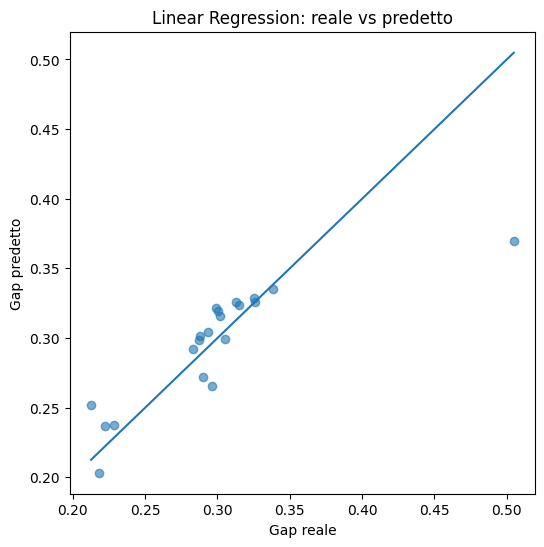

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(Y_test, Y_pred_lin, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()])
plt.xlabel("Gap reale")
plt.ylabel("Gap predetto")
plt.title("Linear Regression: reale vs predetto")
plt.show()

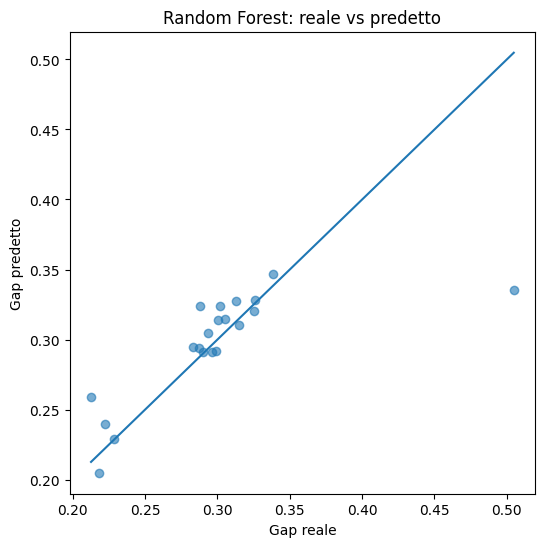

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, Y_pred_rf, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()])
plt.xlabel("Gap reale")
plt.ylabel("Gap predetto")
plt.title("Random Forest: reale vs predetto")
plt.show()

In [47]:
errors_lin = Y_test - Y_pred_lin
errors_rf = Y_test - Y_pred_rf

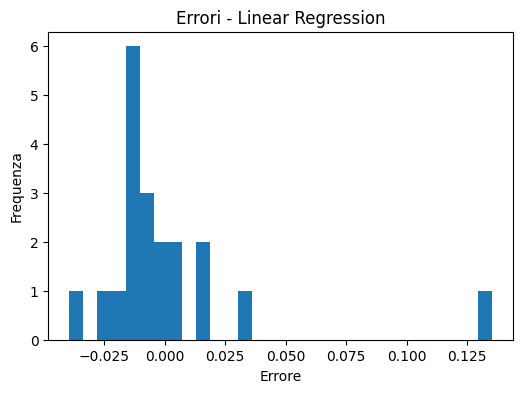

In [48]:
plt.figure(figsize=(6, 4))
plt.hist(errors_lin, bins=30)
plt.xlabel("Errore")
plt.ylabel("Frequenza")
plt.title("Errori - Linear Regression")
plt.show()

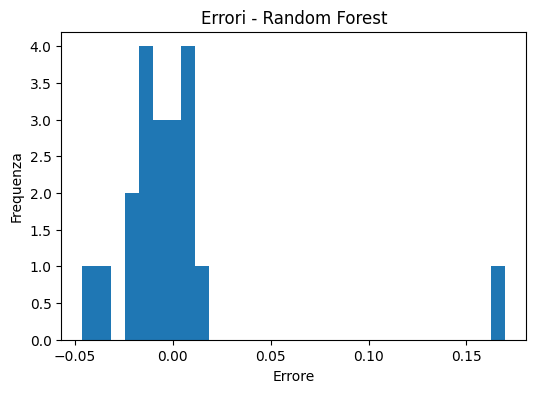

In [49]:
plt.figure(figsize=(6, 4))
plt.hist(errors_rf, bins=30)
plt.xlabel("Errore")
plt.ylabel("Frequenza")
plt.title("Errori - Random Forest")
plt.show()